# M6 — Notebook 03 · Batch B, the slow layers

**Batch B of the 16 M6 geomatics variables** — landscape and settlement structure. These change
over years, not weeks.

| # | Variable | Source | Native res | Vintage available |
|---|---|---|---|---|
| 5  | Built-up fraction | Impact Observatory `io-lulc-annual-v02` | 10 m | annual |
| 12 | Forest / tree fraction | same land-cover product | 10 m | annual |
| 16 | Cropland fraction *(batch D, free here)* | same land-cover product | 10 m | annual |
| 8  | Fragmentation — edge density, LPI, diversity | derived from the land cover | 30 m | one epoch |
| 11 | Surface water — occurrence, permanence, distance | JRC Global Surface Water | 30 m | 2020 epoch |
| 6  | Population density | WorldPop UN-adjusted | 100 m | annual to 2020 |
| 7  | Nighttime lights | HREA (VIIRS-derived) | ~500 m | annual to 2019 |

### What this notebook has to be honest about

`docs/M6.md` §6 sets a vintage-matching QC gate: *"match every layer's year to the analysis
window... never weight 2018 exposure with 2020 population."* **No batch-B source reaches the end
of the Sri Lanka window (2018–2025).** Land cover stops in 2023, population in 2020, nightlights
in 2019, and surface water is a single 2020 epoch.

So these layers cannot all be vintage-matched, and pretending otherwise would quietly violate the
gate. Instead: build annually wherever a source allows it, **carry the last available year forward
for the rest of the window, and record every carry-forward explicitly** (§11). A reader can then
see exactly which district-weeks rest on extrapolated structure. How much that costs depends on
whether these layers move at all within the window — §4 measures that rather than assuming it.

### What this notebook does

1. Assert we are on the frame notebooks 00–02 validated
2. State the vintage gap up front, before any feature is built (§2)
3. Stream 10 m land cover — a billion pixels an island-year — without holding it (§4)
4. Derive fragmentation from that same land cover rather than a second product (§5)
5. Surface water, population and nightlights (§6–8)
6. **Cross-check batch B against batches A and C** (§10) — independent products that should agree
7. Freeze with a vintage audit and provenance

**No account, no API key.** Planetary Computer signs anonymously; WorldPop is a plain download.

---

## 1 · Setup, and assert the chain

In [1]:
import json, hashlib, time, urllib.request
from pathlib import Path
from collections import namedtuple

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.features
from rasterio.windows import from_bounds, Window
from scipy import ndimage
import pystac_client
import planetary_computer as pc
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((QUAR / "nb00_provenance.json").read_text())
prov1 = json.loads((QUAR / "nb01_provenance.json").read_text())
prov2 = json.loads((QUAR / "nb02_provenance.json").read_text())

rdhs = gpd.read_file(GEOM)
sha_now = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
assert sha_now == prov0["geometry_sha256_16"], "geometry changed since notebook 00 — stop"
assert prov1["geometry_sha256_16"] == sha_now, "notebook 01 ran on a different geometry — stop"
assert prov2["geometry_sha256_16"] == sha_now, "notebook 02 ran on a different geometry — stop"

N_UNITS = len(rdhs)
SEED = prov0["seed"]
CRS_EA = prov0["crs_equal_area"]
AREA_KM2 = (rdhs.to_crs(CRS_EA).area / 1e6).values      # equal-area, from notebook 00

cat = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
BBOX = list(rdhs.total_bounds)

print("frame verified against notebooks 00, 01 and 02")
print("  units          :", N_UNITS)
print("  batch A        :", prov1["n_features"], "features ->", prov1["output_sha256_16"])
print("  batch C LST    :", prov2["lst"]["n_composites"], "composites ->", prov2["lst"]["sha256_16"])
print("  batch C VI     :", prov2["vi"]["n_composites"], "composites ->", prov2["vi"]["sha256_16"])
print("  island area    : %.0f km2" % AREA_KM2.sum())

frame verified against notebooks 00, 01 and 02
  units          : 26
  batch A        : 21 features -> 1ef4bc27298b7082
  batch C LST    : 350 composites -> 1c0950fc4f25ca82
  batch C VI     : 177 composites -> 824cd1d1fdffa510
  island area    : 66041 km2


## 2 · The vintage gap, stated before anything is built

Check what each source actually offers against the window we need, rather than discovering the
shortfall after the features are in a model. The `gap_years` column is the number of years at the
end of the window that will rest on a carried-forward value.

In [2]:
WIN_START_YEAR, WIN_END_YEAR = 2018, 2025

def lulc_years():
    items = list(cat.search(collections=["io-lulc-annual-v02"], bbox=BBOX).items())
    return sorted({int(i.properties["start_datetime"][:4]) for i in items})

def hrea_years():
    items = list(cat.search(collections=["hrea"], bbox=BBOX).items())
    return sorted({i.datetime.year for i in items})

LULC_YEARS = [y for y in lulc_years() if WIN_START_YEAR <= y <= WIN_END_YEAR]
HREA_YEARS = [y for y in hrea_years() if WIN_START_YEAR <= y <= WIN_END_YEAR]
POP_YEARS  = [y for y in (2018, 2019, 2020) if y <= WIN_END_YEAR]   # WorldPop global series ends 2020
GSW_EPOCH  = 2020

vintage = pd.DataFrame([
    ("built-up / forest / cropland", "io-lulc-annual-v02", "annual", LULC_YEARS[0], LULC_YEARS[-1]),
    ("fragmentation",                "derived from land cover", "one epoch", GSW_EPOCH, GSW_EPOCH),
    ("surface water",                "JRC GSW v1.4", "cumulative epoch", GSW_EPOCH, GSW_EPOCH),
    ("population density",           "WorldPop UN-adj", "annual", POP_YEARS[0], POP_YEARS[-1]),
    ("nighttime lights",             "HREA (VIIRS-derived)", "annual", HREA_YEARS[0], HREA_YEARS[-1]),
], columns=["layer", "source", "cadence", "first_year", "last_year"])
vintage["gap_years"] = WIN_END_YEAR - vintage["last_year"]

print(f"analysis window: {WIN_START_YEAR}-{WIN_END_YEAR}\n")
print(vintage.to_string(index=False))
print(f"\nland-cover years to build: {LULC_YEARS}")
print(f"nightlight years to build: {HREA_YEARS}")
assert vintage["gap_years"].max() > 0, "no gap — the vintage discussion below is stale, revise it"

analysis window: 2018-2025

                       layer                  source          cadence  first_year  last_year  gap_years
built-up / forest / cropland      io-lulc-annual-v02           annual        2018       2023          2
               fragmentation derived from land cover        one epoch        2020       2020          5
               surface water            JRC GSW v1.4 cumulative epoch        2020       2020          5
          population density         WorldPop UN-adj           annual        2018       2020          5
            nighttime lights    HREA (VIIRS-derived)           annual        2018       2019          6

land-cover years to build: [2018, 2019, 2020, 2021, 2022, 2023]
nightlight years to build: [2018, 2019]


Every layer has a gap; nightlights has the largest. That is not a reason to drop them — a
district's built-up fraction in 2025 is far better approximated by its 2023 value than by nothing
— but it does mean **§11 has to report the carry-forward, and the write-up has to state it.**

Built-up is the layer where a gap would bite hardest, since settlement is the one thing here that
genuinely grows — §4 tests how much it actually moves. Surface water is the least affected: JRC's
occurrence is a *cumulative* 1984–2020 statistic, so it is closer to a true constant than to a
snapshot that goes stale.

## 3 · Machinery carried over from notebook 02

These four functions are **transcribed unchanged from notebook 02**, not rewritten. Both notebooks
must reduce pixels to districts identically or batch B and batch C would not be comparable, and
re-implementing working code is the most reliable way to introduce a discrepancy.

One addition, marked in `zonal`: an optional per-pixel weight. Notebook 02 worked entirely in
MODIS sinusoidal, which is equal-area, so every pixel counted the same. Three sources here
(surface water, population, nightlights) are stored in **EPSG:4326, where a pixel's ground area
shrinks with cos(latitude)**. An unweighted district mean over those would over-weight the
district's northern edge. It is a sub-1% effect across Sri Lanka, but it costs one line.

In [3]:
Grid = namedtuple("Grid", "crs res left top H W transform")

def snap_grid(href, pad=2):
    """Snap a small mosaic window to the native grid the raster sits on."""
    with rasterio.open(pc.sign(href)) as s:
        crs, T, res = s.crs, s.transform, s.res[0]
    minx, miny, maxx, maxy = rdhs.to_crs(crs).total_bounds
    left = T.c + np.floor((minx - T.c) / res) * res - pad * res
    top  = T.f - np.floor((T.f - maxy) / res) * res + pad * res
    W = int(np.ceil((maxx - left) / res)) + pad
    H = int(np.ceil((top - miny) / res)) + pad
    return Grid(crs, res, left, top, H, W,
                rasterio.transform.from_origin(left, top, res, res))

def _read_window(href, g):
    """One tile -> (subarray, dest_row, dest_col), or None if it misses the window."""
    with rasterio.open(pc.sign(href)) as s:
        w = from_bounds(g.left, g.top - g.H * g.res, g.left + g.W * g.res, g.top,
                        transform=s.transform).round_offsets().round_lengths()
        c0, r0 = max(0, int(w.col_off)), max(0, int(w.row_off))
        c1 = min(s.width,  int(w.col_off + w.width))
        r1 = min(s.height, int(w.row_off + w.height))
        if c1 <= c0 or r1 <= r0:
            return None
        sub = s.read(1, window=Window(c0, r0, c1 - c0, r1 - r0))
    return sub, r0 - int(w.row_off), c0 - int(w.col_off)

def read_placed(hrefs, g, dtype="float32", tries=3):
    """Mosaic tiles into the grid by extent. Returns (array, covered_mask)."""
    out = np.zeros((g.H, g.W), dtype=dtype)
    got = np.zeros((g.H, g.W), dtype=bool)
    for href in hrefs:
        for k in range(tries):
            try:
                r = _read_window(href, g)
                break
            except Exception:
                if k == tries - 1:
                    raise
                time.sleep(2 ** k)
        if r is None:
            continue
        sub, dr, dc = r
        out[dr:dr + sub.shape[0], dc:dc + sub.shape[1]] = sub
        got[dr:dr + sub.shape[0], dc:dc + sub.shape[1]] = True
    return out, got

def rasterize_units(g):
    z = rasterio.features.rasterize(
        ((geom, i + 1) for i, geom in enumerate(rdhs.to_crs(g.crs).geometry)),
        out_shape=(g.H, g.W), transform=g.transform, fill=0, dtype="uint16")
    return z, np.bincount(z.ravel(), minlength=N_UNITS + 1)[1:]

def zonal(arr, zones, npx, w=None):
    """Per-unit mean, SD, raw sum and valid fraction.

    `w` is the one addition to notebook 02's version: a per-pixel weight, used to correct
    cos(latitude) area shrink on EPSG:4326 rasters. `sum` stays UNweighted on purpose —
    WorldPop pixels are people-per-pixel, and a count must not be re-weighted.
    """
    ok = np.isfinite(arr) & (zones > 0)
    z = zones[ok].astype(np.int64)
    v = arr[ok].astype(np.float64)
    ww = np.ones_like(v) if w is None else np.broadcast_to(w, arr.shape)[ok].astype(np.float64)
    n   = np.bincount(z, minlength=N_UNITS + 1)[1:]
    sw  = np.bincount(z, weights=ww,          minlength=N_UNITS + 1)[1:]
    s   = np.bincount(z, weights=ww * v,      minlength=N_UNITS + 1)[1:]
    ss  = np.bincount(z, weights=ww * v * v,  minlength=N_UNITS + 1)[1:]
    raw = np.bincount(z, weights=v,           minlength=N_UNITS + 1)[1:]
    mean = np.where(sw > 0, s / np.maximum(sw, 1e-12), np.nan)
    sd   = np.where(n > 1, np.sqrt(np.maximum(ss / np.maximum(sw, 1e-12) - mean ** 2, 0)), np.nan)
    return {"mean": mean, "sd": sd, "sum": raw, "cov": n / np.maximum(npx, 1)}

def coslat_weights(g):
    """cos(latitude) per row, for a geographic grid."""
    lat = g.top - (np.arange(g.H) + 0.5) * g.res
    return np.cos(np.deg2rad(lat))[:, None]

print("machinery ready (transcribed from notebook 02, plus optional cos-lat weighting)")

machinery ready (transcribed from notebook 02, plus optional cos-lat weighting)


## 4 · Land cover at 10 m — stream it, don't hold it

Impact Observatory's annual product is 10 m. Sri Lanka at 10 m is **~1.1 billion pixels per
year**, which is a 1.1 GB array before anything is computed with it, and we want six years. So it
is never held: read horizontal strips, rasterize the 26 districts for that strip alone, add the
(district × class) counts into a running matrix, discard the strip.

Chosen over ESA WorldCover, which is the more familiar product, for one reason: WorldCover exists
only for 2020 and 2021, while this is annual — and §2 just established that vintage is the binding
constraint here. One product then supplies built-up, forest and cropland, all mutually consistent
and all year-matched.

### First, throw out the tile from the wrong side of the planet

A bounding-box search on this collection returns **three** granules for Sri Lanka: `44P`, `44N`
and `01N`. The last is UTM **zone 1** — the Pacific, roughly 100° of longitude away.

It is worth seeing why that is dangerous rather than merely untidy. MGRS tiles in different zones
share the same local coordinate frame, so `01N`'s bounds are *numerically identical* to `44N`'s:
both run x 166,030–833,970, y 0–885,500. Any code that computes a read window from coordinates
alone — which is exactly what the mosaicking function does — will find a perfectly good overlap
with the Pacific tile and paste ocean nodata straight over the island. No error, no warning; the
land cover simply comes back empty for whichever districts it lands on.

Notebook 02 hit the same shape of problem with MODIS tiles `v07`/`v08`. The defence is the same:
**decide membership by the granule's real extent in its own CRS, never by numbers alone.**

In [4]:
IO_CLASS = {0: "nodata", 1: "water", 2: "trees", 4: "flooded_veg", 5: "crops",
            7: "built", 8: "bare", 9: "snow_ice", 10: "clouds", 11: "rangeland"}
N_CLASS = 12
STRIP = 2048

LULC_CSV = QUAR / "m6_batchB_landcover_by_year.csv"
PROBE_YEAR = LULC_YEARS[0]

def covers_island(item, asset="data"):
    """Does this granule's real extent contain the island, in its own CRS?"""
    with rasterio.open(pc.sign(item.assets[asset].href)) as s:
        b, gb = s.bounds, rdhs.to_crs(s.crs).total_bounds
    return gb[0] < b.right and gb[2] > b.left and gb[1] < b.top and gb[3] > b.bottom

_probe = [i for i in cat.search(collections=["io-lulc-annual-v02"], bbox=BBOX,
                                datetime=f"{PROBE_YEAR}-01-01/{PROBE_YEAR}-12-31").items()
          if i.properties["start_datetime"][:4] == str(PROBE_YEAR)]
for i in _probe:
    print(f"  {i.id:<12} EPSG:{i.properties['proj:epsg']}  covers island: {covers_island(i)}")

LULC_EPSG = sorted({i.properties["proj:epsg"] for i in _probe if covers_island(i)})
assert len(LULC_EPSG) == 1, f"expected one UTM zone over Sri Lanka, got {LULC_EPSG}"
LULC_EPSG = LULC_EPSG[0]
print(f"\nkeeping only EPSG:{LULC_EPSG} granules")

def lulc_items(year):
    """Granules for one year, restricted to the UTM zone that actually contains the island."""
    return [i for i in cat.search(collections=["io-lulc-annual-v02"], bbox=BBOX,
                                  datetime=f"{year}-01-01/{year}-12-31").items()
            if i.properties["start_datetime"][:4] == str(year)
            and i.properties["proj:epsg"] == LULC_EPSG]

def landcover_counts(year):
    """(26 x N_CLASS) pixel counts, streamed strip by strip."""
    counts = np.zeros((N_UNITS + 1, N_CLASS), dtype=np.int64)
    for it in lulc_items(year):
        with rasterio.open(pc.sign(it.assets["data"].href)) as s:
            geom = rdhs.to_crs(s.crs)
            minx, miny, maxx, maxy = geom.total_bounds
            w = from_bounds(minx, miny, maxx, maxy,
                            transform=s.transform).round_offsets().round_lengths()
            c0, r0 = max(0, int(w.col_off)), max(0, int(w.row_off))
            c1 = min(s.width,  int(w.col_off + w.width))
            r1 = min(s.height, int(w.row_off + w.height))
            if c1 <= c0 or r1 <= r0:
                continue
            for rs in range(r0, r1, STRIP):
                re_ = min(rs + STRIP, r1)
                win = Window(c0, rs, c1 - c0, re_ - rs)
                a = s.read(1, window=win)
                z = rasterio.features.rasterize(
                    ((g, i + 1) for i, g in enumerate(geom.geometry)),
                    out_shape=a.shape, transform=s.window_transform(win),
                    fill=0, dtype="uint16")
                m = z > 0
                if m.any():
                    k = z[m].astype(np.int64) * N_CLASS + np.clip(a[m], 0, N_CLASS - 1)
                    counts += np.bincount(k, minlength=(N_UNITS + 1) * N_CLASS
                                          ).reshape(N_UNITS + 1, N_CLASS)
    return counts[1:]

done = set()
if LULC_CSV.exists():
    done = set(pd.read_csv(LULC_CSV)["year"].unique())

rows, t0 = [], time.time()
for year in [y for y in LULC_YEARS if y not in done]:
    tY = time.time()
    counts = landcover_counts(year)
    tot = counts.sum(1)
    frac = counts / np.maximum(tot, 1)[:, None]
    df = pd.DataFrame({"year": year, "rdhs_id": rdhs["rdhs_id"].values,
                       "rdhs_name": rdhs["rdhs_name"].values, "lc_n_px": tot})
    for c, name in IO_CLASS.items():
        if name not in ("nodata", "snow_ice", "clouds"):
            df[f"frac_{name}"] = frac[:, c]
    rows.append(df)
    print(f"  {year}: {tot.sum()/1e6:,.0f} M px in {time.time()-tY:.0f}s   "
          f"built {100*frac[:, 7].mean():.1f}%  trees {100*frac[:, 2].mean():.1f}%")

if rows:
    pd.concat(rows).to_csv(LULC_CSV, mode="a", header=not LULC_CSV.exists(), index=False)
lc = pd.read_csv(LULC_CSV).drop_duplicates(["year", "rdhs_id"]).sort_values(["year", "rdhs_id"])
print(f"\nland cover: {lc.shape}  years {sorted(lc.year.unique())}  ({time.time()-t0:.0f}s)")

area_check = (lc[lc.year == lc.year.max()]["lc_n_px"].values * 100 / 1e6)
print(f"rasterized area {area_check.sum():,.0f} km2 vs vector {AREA_KM2.sum():,.0f} km2 "
      f"({100*(area_check.sum()/AREA_KM2.sum()-1):+.2f}%)")

  44P-2018     EPSG:32644  covers island: True


  44N-2018     EPSG:32644  covers island: True

keeping only EPSG:32644 granules

land cover: (156, 11)  years [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]  (0s)
rasterized area 66,218 km2 vs vector 66,041 km2 (+0.27%)


Look at the most recent year, and at what moved across the record.

In [5]:
REF_YEAR = max(LULC_YEARS)
ref = lc[lc.year == REF_YEAR].set_index("rdhs_name")
cols = [c for c in ref.columns if c.startswith("frac_")]
print(f"land-cover composition, {REF_YEAR}\n")
print((100 * ref[cols]).round(1).sort_values("frac_built", ascending=False).to_string())

land-cover composition, 2023

              frac_water  frac_trees  frac_flooded_veg  frac_crops  frac_built  frac_bare  frac_rangeland
rdhs_name                                                                                                
Colombo              2.2        25.7               0.0         6.9        63.1        0.3             1.8
Gampaha              3.0        29.1               0.3         8.8        57.3        0.0             1.4
Jaffna               9.6         4.8               7.0        10.4        32.7        2.0            33.3
Kandy                1.7        58.4               0.0         4.4        28.6        0.0             6.8
Kurunegala           2.0        48.9               0.1        22.3        20.6        0.0             5.3
Matara               0.7        69.0               0.2         8.5        20.1        0.0             1.7
Kalutara             1.2        67.7               0.0         9.3        20.1        0.0             1.6
Hambantota      

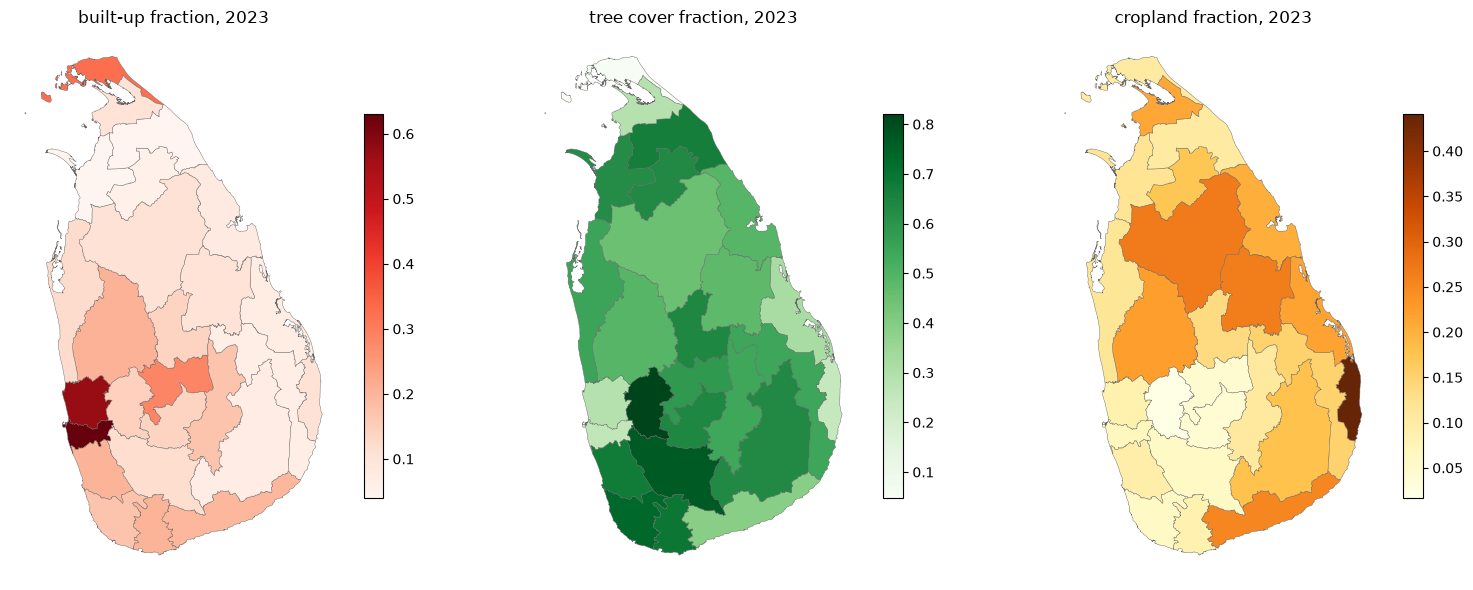

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
gj = rdhs.set_index("rdhs_name").join(ref[["frac_built", "frac_trees", "frac_crops"]])
for ax, (c, cmap, t) in zip(axes, [("frac_built", "Reds", "built-up"),
                                   ("frac_trees", "Greens", "tree cover"),
                                   ("frac_crops", "YlOrBr", "cropland")]):
    gj.plot(column=c, cmap=cmap, legend=True, ax=ax, edgecolor="0.4", linewidth=.3,
            legend_kwds={"shrink": .7})
    ax.set_title(f"{t} fraction, {REF_YEAR}"); ax.set_axis_off()
plt.tight_layout()

### Is the annual signal real, or is it classifier noise?

This decides whether annual land cover is worth joining year-by-year at all, and how much the
carry-forward in §11 costs. Real urbanisation is close to monotonic — built-up does not
un-build. So compare the **net** change across the record against the **year-to-year** movement:
if a layer wobbles by more each year than it moves in total, the annual signal is mostly the
classifier changing its mind, and treating it as a time series would feed that noise to the model.

      frac_built  frac_trees
year                        
2018       16.68       50.99
2019       17.69       49.64
2020       18.47       49.28
2021       18.02       51.36
2022       18.29       50.86
2023       17.29       51.96

island built-up: 16.68% (2018) -> 17.29% (2023)   peak 18.47% (2020)
median district: net change 0.94 pp, mean year-to-year change 0.76 pp  ->  noise/signal = 0.76
districts moving monotonically across all 6 years: 0/26

fastest-changing districts (pp per year, OLS slope):
rdhs_name
Jaffna          1.155
Killinochchi    1.048
Hambantota      0.474
Puttalam        0.371
Batticaloa      0.270


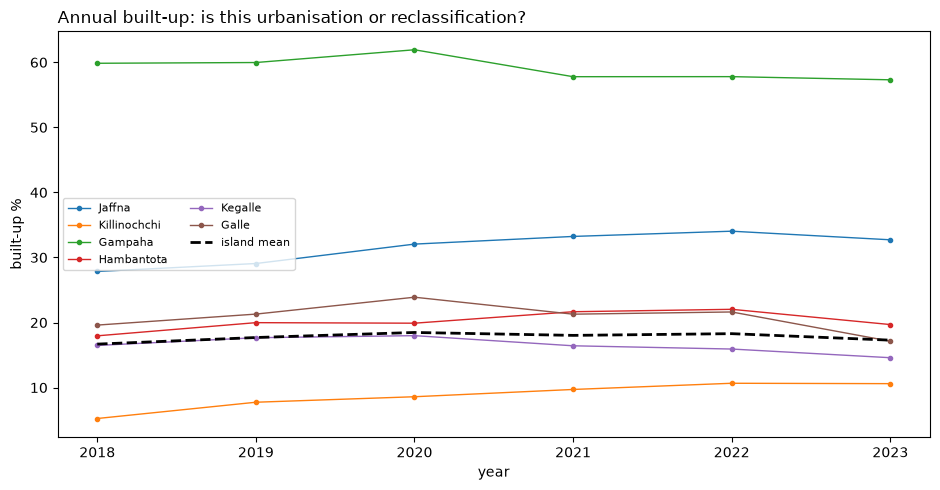

In [7]:
trend = lc.pivot_table(index="year", values=["frac_built", "frac_trees"], aggfunc="mean")
print((100 * trend).round(2).to_string())

per_unit = lc.pivot_table(index="rdhs_name", columns="year", values="frac_built")
years = np.array(sorted(per_unit.columns))
slope = per_unit.apply(lambda r: np.polyfit(r.index.astype(float), r.values, 1)[0] * 100, axis=1)

net   = 100 * (per_unit[years[-1]] - per_unit[years[0]]).abs()          # pp, over the record
yoy   = (100 * per_unit[years].diff(axis=1).abs()).mean(axis=1)         # pp, mean |year-to-year|
ratio = (yoy / net.replace(0, np.nan)).median()

print(f"\nisland built-up: {100*trend['frac_built'].iloc[0]:.2f}% ({years[0]}) -> "
      f"{100*trend['frac_built'].iloc[-1]:.2f}% ({years[-1]})   "
      f"peak {100*trend['frac_built'].max():.2f}% ({trend['frac_built'].idxmax()})")
print(f"median district: net change {net.median():.2f} pp, "
      f"mean year-to-year change {yoy.median():.2f} pp  ->  noise/signal = {ratio:.2f}")

monotone = ((per_unit[years].diff(axis=1).iloc[:, 1:] >= 0).all(axis=1)
            | (per_unit[years].diff(axis=1).iloc[:, 1:] <= 0).all(axis=1)).sum()
print(f"districts moving monotonically across all {len(years)} years: {monotone}/{N_UNITS}")
print("\nfastest-changing districts (pp per year, OLS slope):")
print(slope.sort_values(ascending=False).head(5).round(3).to_string())

fig, ax = plt.subplots(figsize=(9.5, 5))
for name in slope.abs().sort_values(ascending=False).head(6).index:
    ax.plot(per_unit.columns, 100 * per_unit.loc[name], marker="o", ms=3, lw=1, label=name)
ax.plot(trend.index, 100 * trend["frac_built"], color="k", lw=2, ls="--", label="island mean")
ax.set_ylabel("built-up %"); ax.set_xlabel("year")
ax.set_title("Annual built-up: is this urbanisation or reclassification?", loc="left")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

**Read the numbers above before using these as a time series.** The island mean does not climb
monotonically — it peaks mid-record and falls back — and few districts move in one direction
across all years. A physical process that only adds buildings cannot do that, so a large part of
the year-to-year movement is the classifier relabelling the same ground, not construction.

Two districts do stand out with changes far above the wobble (Jaffna and Killinochchi, both in the
post-conflict north, where genuine resettlement is well documented) — so the product is not
uninformative, it is just noisy relative to the size of the real signal in most districts.

The consequence for notebook 04: **do not feed annual built-up as a per-year predictor.** Use a
single epoch, or a multi-year mean per district, and treat the annual tables as evidence about
uncertainty rather than as a trend to be tracked. The per-year CSV is frozen either way so that
choice stays reversible and inspectable.

## 5 · Fragmentation, from the land cover already loaded

`docs/M6.md` §Batch B suggests `pylandstats`. Not installed, and not needed for three metrics that
are a dozen lines of `scipy.ndimage` — so they are written here where they can be read, rather
than adding a dependency to hide them behind.

- **Shannon diversity** of the class fractions — how mixed the district is
- **Edge density** — metres of class boundary per km²; the standard fragmentation proxy
- **Largest patch index** — the biggest single contiguous patch as a share of the district

Two honest caveats. **Edge density is resolution-dependent** — a finer grid finds more edges — so
the resolution is fixed and reported, and the numbers are comparable across districts but not
against a study using a different one. And this is computed at **30 m, not 10 m**: connected-
component labelling on a district at 10 m needs several hundred MB per district for no meaningful
gain in a district-level summary.

In [8]:
FRAG_RES_M = 30
STRIDE = FRAG_RES_M // 10

def district_grid(idx, href):
    """A 10 m grid snapped to the product's own grid, covering one district's bbox.

    Same snapping rule as `snap_grid`, but around a single unit rather than the island —
    several districts straddle the 44N/44P tile seam, so the two tiles must be placed into
    one shared frame. Reading each tile into its own array and combining them is what breaks:
    the pieces have different shapes.
    """
    with rasterio.open(pc.sign(href)) as s:
        crs, T, res = s.crs, s.transform, s.res[0]
    minx, miny, maxx, maxy = rdhs.iloc[[idx]].to_crs(crs).total_bounds
    left = T.c + np.floor((minx - T.c) / res) * res
    top  = T.f - np.floor((T.f - maxy) / res) * res
    W = int(np.ceil((maxx - left) / res)) + 1
    H = int(np.ceil((top - miny) / res)) + 1
    return Grid(crs, res, left, top, H, W,
                rasterio.transform.from_origin(left, top, res, res))

def district_landcover(idx, items):
    """One district at FRAG_RES_M: mosaic its bbox across tiles, subsample, mask to polygon."""
    g = district_grid(idx, items[0].assets["data"].href)
    a, got = read_placed([i.assets["data"].href for i in items], g, dtype="uint8")
    a = np.where(got, a, 0)[::STRIDE, ::STRIDE]
    tr = g.transform * rasterio.Affine.scale(STRIDE, STRIDE)
    m = rasterio.features.geometry_mask(rdhs.iloc[[idx]].to_crs(g.crs).geometry,
                                        out_shape=a.shape, transform=tr, invert=True)
    return np.where(m, a, 0).astype("uint8")

frag = []
ref_items = lulc_items(REF_YEAR)
t0 = time.time()
for i, name in enumerate(rdhs["rdhs_name"]):
    a = district_landcover(i, ref_items)
    inside = a > 0
    n_in = int(inside.sum())

    p = np.bincount(a[inside], minlength=N_CLASS) / max(n_in, 1)
    p = p[p > 0]
    shannon = float(-(p * np.log(p)).sum())

    # 4-neighbour boundaries where both pixels are inside the district and classes differ
    edges = int(((a[:, :-1] != a[:, 1:]) & inside[:, :-1] & inside[:, 1:]).sum()
                + ((a[:-1] != a[1:]) & inside[:-1] & inside[1:]).sum())
    area_m2 = n_in * FRAG_RES_M ** 2
    edge_density = edges * FRAG_RES_M / area_m2 * 1e6          # m of edge per km2

    # Largest patch index: label EACH class separately and take the biggest patch found.
    # Labelling the non-zero mask as a whole would fuse a forest patch to the cropland
    # touching it and report the district as one giant patch.
    biggest, biggest_built = 0, 0
    for cls in np.unique(a[inside]):
        lab, nlab = ndimage.label((a == cls) & inside)
        if not nlab:
            continue
        sz = np.bincount(lab.ravel())[1:].max()
        biggest = max(biggest, int(sz))
        if cls == 7:
            biggest_built = int(sz)
    lpi = 100 * biggest / max(n_in, 1)
    built_lpi = 100 * biggest_built / max(n_in, 1)

    frag.append({"rdhs_id": rdhs["rdhs_id"].iloc[i], "rdhs_name": name,
                 "lc_shannon": shannon, "edge_density_m_km2": edge_density,
                 "lpi_pct": lpi, "built_lpi_pct": built_lpi, "frag_n_px": n_in})
    del a

frag = pd.DataFrame(frag)
print(f"fragmentation for {len(frag)} districts at {FRAG_RES_M} m in {time.time()-t0:.0f}s\n")
print(frag.set_index("rdhs_name")[["lc_shannon", "edge_density_m_km2", "lpi_pct", "built_lpi_pct"]]
        .round(1).sort_values("edge_density_m_km2", ascending=False).to_string())

fragmentation for 26 districts at 30 m in 42s

              lc_shannon  edge_density_m_km2  lpi_pct  built_lpi_pct
rdhs_name                                                           
Kurunegala           1.3              6884.8      5.9            1.3
Puttalam             1.3              5526.7     30.9            3.5
Badulla              1.3              5005.8     46.5            6.9
Nuwara Eliya         1.1              4969.4     46.7            1.8
Jaffna               1.6              4922.5     13.2           13.2
Gampaha              1.1              4921.7     50.5           50.5
Hambantota           1.4              4714.0     16.7            2.1
Anuradhapura         1.4              4713.3     14.8            1.4
Batticaloa           1.5              4213.4     15.6            1.6
Killinochchi         1.6              4160.9     16.2            3.3
Kandy                1.1              4078.6     29.3           21.0
Colombo              1.0              4001.2     56.4   

## 6 · Surface water

JRC Global Surface Water. **Occurrence** is the share of the 1984–2020 record in which a pixel was
water — a cumulative statistic, which is why this layer suffers least from the vintage gap.

Three features, plus the one that actually matters epidemiologically: **distance to permanent
water**. *Aedes aegypti* is a container breeder rather than a marsh species, so proximity to
permanent water is a weaker driver here than it would be for *Anopheles* — it is carried because
`M6.md` asks for it and because it proxies low-lying wet terrain, not because standing rivers
breed the vector.

The distance transform runs on a 250 m grid: an exact 30 m transform over the island allocates
several gigabytes to resolve a distance that is then averaged over a whole district.

In [9]:
gsw = list(cat.search(collections=["jrc-gsw"], bbox=BBOX).items())
print("GSW tiles:", [i.id for i in gsw])

G_W = snap_grid(gsw[0].assets["occurrence"].href)
zw, npxw = rasterize_units(G_W)
print(f"grid {G_W.H} x {G_W.W} at {G_W.res*111320:.0f} m")

occ, got_w = read_placed([i.assets["occurrence"].href for i in gsw], G_W)
occ = np.where(got_w & (occ <= 100), occ, np.nan)             # 255 = no data
wgt = coslat_weights(G_W)

zo = zonal(occ, zw, npxw, w=wgt)
water_any  = zonal(np.where(np.isfinite(occ), (occ >= 25).astype(float), np.nan), zw, npxw, w=wgt)
water_perm = zonal(np.where(np.isfinite(occ), (occ >= 90).astype(float), np.nan), zw, npxw, w=wgt)

print(f"occurrence: {np.nanmin(occ):.0f}..{np.nanmax(occ):.0f}  "
      f"coverage {np.isfinite(occ)[zw>0].mean():.1%} of land px")

GSW tiles: ['80E_10Nv1_3_2020', '70E_10Nv1_3_2020']


grid 15674 x 9436 at 28 m


occurrence: 0..100  coverage 100.0% of land px


permanent water: 0.85% of land pixels
             rdhs_id  water_occurrence_mean  water_frac  permanent_water_frac  dist_permanent_water_km
rdhs_name                                                                                             
Kalmunai     RDHS_25                  5.186       0.063                 0.026                    3.533
Gampaha      RDHS_02                  2.363       0.024                 0.022                   11.849
Trincomalee  RDHS_16                  3.546       0.043                 0.021                    4.036
Mullaitivu   RDHS_13                  4.159       0.054                 0.019                    4.840
Puttalam     RDHS_18                  2.643       0.033                 0.015                    5.394
Jaffna       RDHS_10                  7.305       0.102                 0.015                    1.826
Ampara       RDHS_26                  2.585       0.034                 0.014                    7.266
Polonnaruwa  RDHS_20               

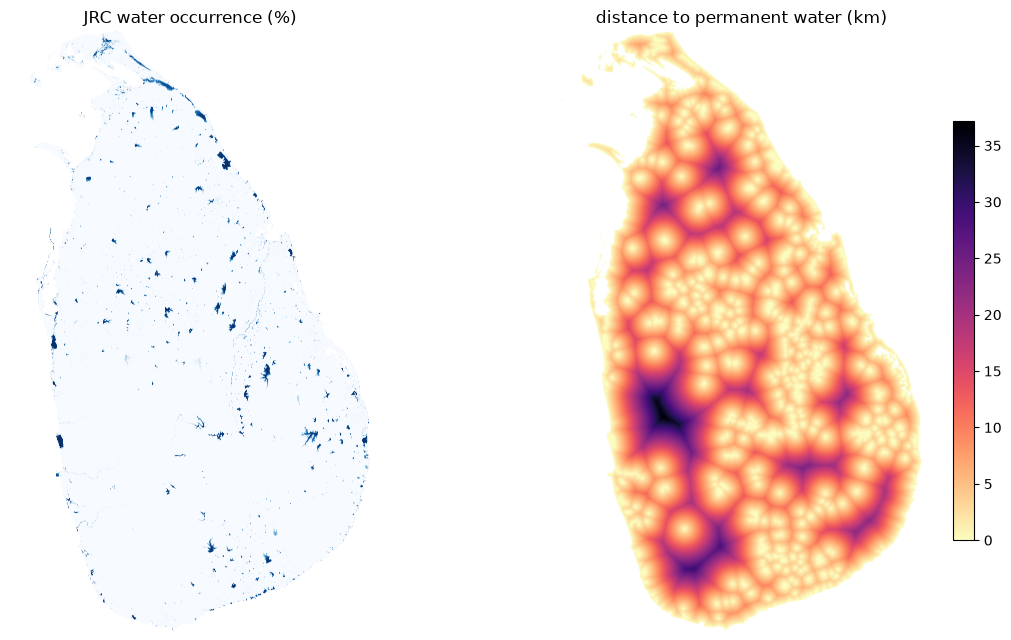

In [10]:
# distance to permanent water, on a 250 m grid built by block-max from the 30 m mask
BLOCK = 8
perm = np.nan_to_num(occ, nan=0) >= 90
h, w_ = (perm.shape[0] // BLOCK) * BLOCK, (perm.shape[1] // BLOCK) * BLOCK
coarse = perm[:h, :w_].reshape(h // BLOCK, BLOCK, w_ // BLOCK, BLOCK).max(axis=(1, 3))

res_m_y = G_W.res * 111320 * BLOCK
res_m_x = G_W.res * 111320 * np.cos(np.deg2rad(rdhs.total_bounds[[1, 3]].mean())) * BLOCK
dist_km = ndimage.distance_transform_edt(~coarse, sampling=(res_m_y, res_m_x)) / 1000

Gc = Grid(G_W.crs, G_W.res * BLOCK, G_W.left, G_W.top, coarse.shape[0], coarse.shape[1],
          rasterio.transform.from_origin(G_W.left, G_W.top, G_W.res * BLOCK, G_W.res * BLOCK))
zc, npxc = rasterize_units(Gc)
zd = zonal(dist_km, zc, npxc, w=coslat_weights(Gc))

water = pd.DataFrame({
    "rdhs_id": rdhs["rdhs_id"].values, "rdhs_name": rdhs["rdhs_name"].values,
    "water_occurrence_mean": zo["mean"], "water_frac": water_any["mean"],
    "permanent_water_frac": water_perm["mean"], "dist_permanent_water_km": zd["mean"],
})
print(f"permanent water: {100*perm[zw>0].mean():.2f}% of land pixels")
print(water.set_index("rdhs_name").round(3).sort_values("permanent_water_frac",
      ascending=False).head(8).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))
axes[0].imshow(np.where(zw > 0, occ, np.nan), cmap="Blues", vmin=0, vmax=100)
axes[0].set_title("JRC water occurrence (%)"); axes[0].set_axis_off()
im = axes[1].imshow(np.where(zc > 0, dist_km, np.nan), cmap="magma_r")
axes[1].set_title("distance to permanent water (km)"); axes[1].set_axis_off()
plt.colorbar(im, ax=axes[1], shrink=.7)
plt.tight_layout()

## 7 · Population

WorldPop UN-adjusted, 100 m, annual. Downloaded straight over HTTPS — no portal, no account.

The **sum** is deliberately not cos-latitude weighted: WorldPop pixels are people-per-pixel, a
count, and re-weighting a count would invent people. Density divides that count by the
**equal-area** district area from notebook 00, not by a pixel tally.

The check that matters is the national total against the UN figure — if the sum is off, either the
mask or the product is wrong, and every density built on it is wrong too.

It comes out a few percent under the UN number, and that gap is itself a result rather than an
error to explain away. The cell reports **two** totals: what the raster holds for the country, and
what falls inside the 26 RDHS polygons. Pixels are assigned whole to whichever unit contains their
centre, so a 100 m coastal pixel straddling the boundary is lost entirely — and Sri Lanka is an
island, i.e. all boundary. The shortfall is therefore mostly coastline, not a broken product.

This matters beyond this notebook. WP5's population-weighted exposure build divides by exactly
this denominator, so a systematic coastal deficit would propagate straight into it — and coastal
districts are the dense, dengue-heavy ones. Quantifying it here means WP5 inherits a number rather
than an assumption.

In [11]:
POP_DIR = QUAR / "worldpop"; POP_DIR.mkdir(exist_ok=True)

def worldpop(year):
    """WorldPop UN-adjusted 100 m, cached locally."""
    f = POP_DIR / f"lka_ppp_{year}_UNadj.tif"
    if not f.exists():
        url = (f"https://data.worldpop.org/GIS/Population/Global_2000_2020/"
               f"{year}/LKA/lka_ppp_{year}_UNadj.tif")
        print(f"  downloading {year} ...", end=" ", flush=True)
        urllib.request.urlretrieve(url, f)
        print(f"{f.stat().st_size/1e6:.0f} MB")
    return f

pop_rows, capture = [], {}
for year in POP_YEARS:
    f = worldpop(year)
    with rasterio.open(f) as s:
        gp = Grid(s.crs, s.res[0], s.bounds.left, s.bounds.top, s.height, s.width, s.transform)
        a = s.read(1).astype("float64")
        a = np.where(a == s.nodata, np.nan, a)
    zp, npxp = rasterize_units(gp)
    zs = zonal(a, zp, npxp)
    # Two totals, deliberately: what the product says the country holds, and what our
    # district mask actually captures. The difference is people on pixels whose centre
    # falls outside every RDHS polygon — almost all of them on the coastline.
    raster_total = float(np.nansum(a))
    capture[year] = zs["sum"].sum() / raster_total
    pop_rows.append(pd.DataFrame({
        "year": year, "rdhs_id": rdhs["rdhs_id"].values, "rdhs_name": rdhs["rdhs_name"].values,
        "pop_sum": zs["sum"], "pop_density_km2": zs["sum"] / AREA_KM2}))
    print(f"  {year}: raster {raster_total/1e6:.2f} M   inside districts {zs['sum'].sum()/1e6:.2f} M"
          f"   captured {100*capture[year]:.1f}%")

pop = pd.concat(pop_rows)
national = pop.groupby("year")["pop_sum"].sum() / 1e6
print(f"\nWorldPop UN-adjusted national totals, inside the district mask (M):")
print(national.round(2).to_string())
print(f"\nmean capture fraction: {100*np.mean(list(capture.values())):.1f}%")
print("UN World Population Prospects for Sri Lanka is ~21.4 M (2018) to ~21.9 M (2020).")
assert 19 < national.max() < 24, "national population is implausible — check the mask or product"
assert min(capture.values()) > 0.95, "district mask is losing too much of the population raster"

POP_REF = max(POP_YEARS)
print("\ndensest districts, %d:" % POP_REF)
print(pop[pop.year == POP_REF].set_index("rdhs_name")["pop_density_km2"]
        .sort_values(ascending=False).head(6).round(0).to_string())

  2018: raster 21.23 M   inside districts 20.93 M   captured 98.6%


  2019: raster 21.32 M   inside districts 21.03 M   captured 98.6%


  2020: raster 21.41 M   inside districts 21.12 M   captured 98.6%

WorldPop UN-adjusted national totals, inside the district mask (M):
year
2018    20.93
2019    21.03
2020    21.12

mean capture fraction: 98.6%
UN World Population Prospects for Sri Lanka is ~21.4 M (2018) to ~21.9 M (2020).

densest districts, 2020:
rdhs_name
Colombo     3432.0
Gampaha     1721.0
Kalutara     793.0
Kandy        749.0
Galle        667.0
Matara       635.0


## 8 · Nighttime lights — and a documented substitution

`docs/M6.md` §Batch B asks for **monthly VIIRS DNB** (`NOAA/VIIRS/DNB/MONTHLY_V1`). The monthly
composites are distributed by the Earth Observation Group, which **requires a registered account**
— a genuine access barrier, which the 2026-07-07 decision says is the one legitimate reason to
substitute, with the reason recorded.

Substituted with **HREA**, which is built from the same VIIRS DNB sensor, hosted anonymously, and
annual rather than monthly. The asset taken is `light-composite` — the annual VIIRS radiance
composite, which is the nightlights variable itself.

HREA also carries `lightscore` (modelled probability a settlement is electrified), which
`M6.md` §Batch D flags as a fallback SES proxy if Meta's Relative Wealth Index proves unavailable.
It is **not** extracted here: it is a 30 m field over the whole country, so pulling it costs
hundreds of megabytes for a district mean, and it is a fallback for a problem batch D has not hit
yet. It belongs in that notebook, if RWI actually fails.

The cost of the substitution is that nightlights becomes annual, not monthly, so it can no longer
serve as a *dynamic* predictor — it joins batch B as a slow layer. Given HREA ends in 2019 (§2)
that was true in practice regardless.

In [12]:
hrea_items = {i.datetime.year: i for i in cat.search(collections=["hrea"], bbox=BBOX).items()}
print("HREA years available:", sorted(hrea_items))

nl_rows = []
for year in HREA_YEARS:
    it = hrea_items[year]
    G_N = snap_grid(it.assets["light-composite"].href)
    zn, npxn = rasterize_units(G_N)
    lc_arr, got_n = read_placed([it.assets["light-composite"].href], G_N)
    lc_arr = np.where(got_n & (lc_arr > -1e30), lc_arr, np.nan)
    zl = zonal(lc_arr, zn, npxn, w=coslat_weights(G_N))

    nl_rows.append(pd.DataFrame({
        "year": year, "rdhs_id": rdhs["rdhs_id"].values, "rdhs_name": rdhs["rdhs_name"].values,
        "nightlight_mean": zl["mean"], "nightlight_sd": zl["sd"]}))
    print(f"  {year}: grid {G_N.H}x{G_N.W} at ~{G_N.res*111320:.0f} m, "
          f"mean radiance {np.nanmean(zl['mean']):.2f}")

nl = pd.concat(nl_rows)
NL_REF = max(HREA_YEARS)
print("\nbrightest districts, %d:" % NL_REF)
print(nl[nl.year == NL_REF].set_index("rdhs_name")["nightlight_mean"]
        .sort_values(ascending=False).head(6).round(2).to_string())

HREA years available: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


  2018: grid 945x571 at ~464 m, mean radiance 1.11


  2019: grid 945x571 at ~464 m, mean radiance 1.11

brightest districts, 2019:
rdhs_name
Colombo     1.87
Gampaha     1.57
Kalutara    1.19
Jaffna      1.18
Galle       1.15
Puttalam    1.11


## 9 · Assemble batch B

One row per district, taking the most recent available year of each layer as the district's
value. The per-year tables stay on disk so notebook 04 can join year-matched values where the
vintage allows; this table is the single-epoch summary used for the collinearity and cross-checks
below.

In [13]:
B = (lc[lc.year == REF_YEAR][["rdhs_id", "rdhs_name"] +
                             [c for c in lc.columns if c.startswith("frac_")]]
     .merge(frag.drop(columns="frag_n_px"), on=["rdhs_id", "rdhs_name"])
     .merge(water, on=["rdhs_id", "rdhs_name"])
     .merge(pop[pop.year == POP_REF][["rdhs_id", "pop_sum", "pop_density_km2"]], on="rdhs_id")
     .merge(nl[nl.year == NL_REF][["rdhs_id", "nightlight_mean"]], on="rdhs_id"))

print("batch B table:", B.shape)
print("features:", [c for c in B.columns if c not in ("rdhs_id", "rdhs_name")])
B.head(3).round(3)

batch B table: (26, 20)
features: ['frac_water', 'frac_trees', 'frac_flooded_veg', 'frac_crops', 'frac_built', 'frac_bare', 'frac_rangeland', 'lc_shannon', 'edge_density_m_km2', 'lpi_pct', 'built_lpi_pct', 'water_occurrence_mean', 'water_frac', 'permanent_water_frac', 'dist_permanent_water_km', 'pop_sum', 'pop_density_km2', 'nightlight_mean']


,rdhs_id,rdhs_name,frac_water,frac_trees,frac_flooded_veg,frac_crops,frac_built,frac_bare,frac_rangeland,lc_shannon,edge_density_m_km2,lpi_pct,built_lpi_pct,water_occurrence_mean,water_frac,permanent_water_frac,dist_permanent_water_km,pop_sum,pop_density_km2,nightlight_mean
0,RDHS_01,Colombo,0.022,0.257,0.000,0.069,0.631,0.003,0.018,1.001,4001.246,56.378,56.378,1.779,0.022,0.008,4.379,2362046.487,3432.379,1.866
1,RDHS_02,Gampaha,0.030,0.291,0.003,0.088,0.573,0.000,0.014,1.078,4921.738,50.451,50.451,2.363,0.024,0.022,11.849,2437061.731,1720.602,1.572
2,RDHS_03,Kalutara,0.012,0.677,0.000,0.093,0.201,0.000,0.016,0.931,3789.882,55.956,4.396,0.597,0.007,0.004,8.450,1306879.511,793.495,1.187


14 of 153 pairs exceed |r| > 0.8
  +0.994  water_occurrence_mean ~ water_frac
  +0.976  pop_density_km2 ~ nightlight_mean
  +0.965  frac_water ~ water_occurrence_mean
  +0.959  frac_water ~ water_frac
  +0.952  frac_built ~ built_lpi_pct
  +0.943  built_lpi_pct ~ nightlight_mean
  +0.931  frac_built ~ nightlight_mean
  +0.924  built_lpi_pct ~ pop_density_km2
  +0.911  frac_built ~ pop_density_km2
  +0.886  frac_flooded_veg ~ frac_bare


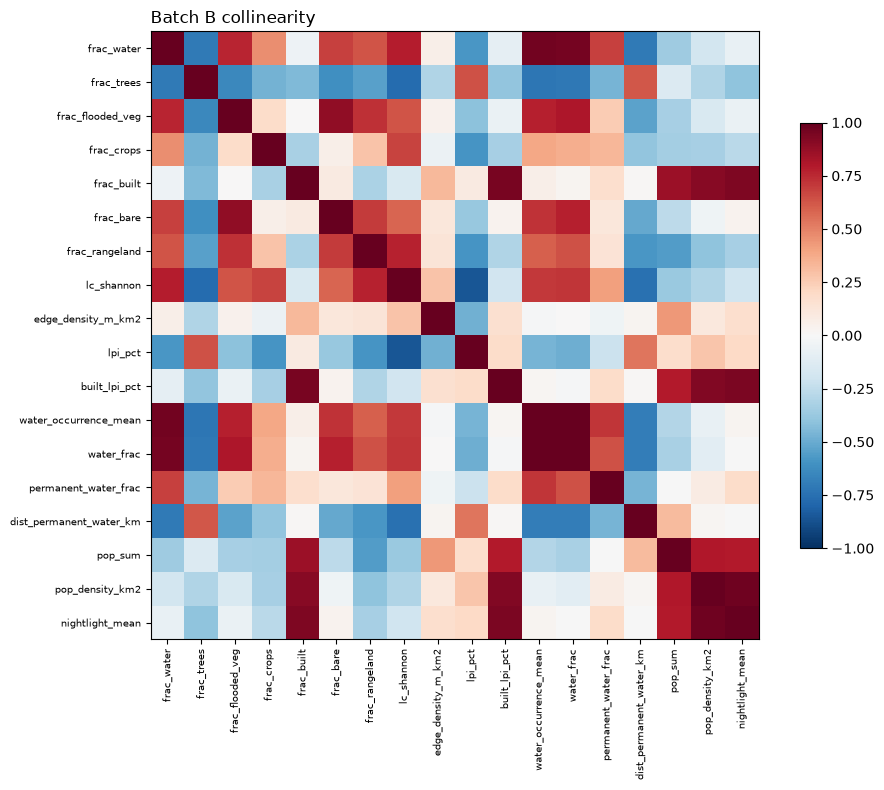

In [14]:
feat_cols = [c for c in B.columns if c not in ("rdhs_id", "rdhs_name")]
corr = B[feat_cols].corr()
hi = [(a, b, corr.loc[a, b]) for i, a in enumerate(feat_cols) for b in feat_cols[i+1:]
      if abs(corr.loc[a, b]) > 0.8]
print(f"{len(hi)} of {len(feat_cols)*(len(feat_cols)-1)//2} pairs exceed |r| > 0.8")
for a, b, v in sorted(hi, key=lambda t: -abs(t[2]))[:10]:
    print(f"  {v:+.3f}  {a} ~ {b}")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_cols))); ax.set_xticklabels(feat_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(feat_cols))); ax.set_yticklabels(feat_cols, fontsize=7)
ax.set_title("Batch B collinearity", loc="left")
plt.colorbar(im, shrink=.7); plt.tight_layout()

## 10 · Cross-check against batches A and C

The strongest validation available: batch B comes from land-cover, water, census-modelled
population and nightlight products that share **no inputs** with the Copernicus DEM of notebook 01
or the MODIS thermal and greenness bands of notebook 02. If these independent measurements agree
on the physical relationships they should have, the extractions are sound. If they disagree, one
of them is wrong.

Four relationships that must hold, each between products that share nothing:

- **tree fraction ↑ → NDVI ↑** — a classifier's tree class against optical greenness
- **greenness ↑ → daytime LST ↓** — evapotranspirative cooling, greenness against thermal
- **nightlights ↑ → built-up ↑** — VIIRS radiance against land-cover structure
- **population density ↑ → built-up ↑** — census-modelled people against classified surface

A fifth is **measured but deliberately not asserted**: built-up against daytime LST, the urban
heat island. It is the textbook expectation and it does not appear at this resolution — see below.

independent-source agreement

  OK    tree cover ~ NDVI                r = +0.865   (expect > +0.40)
  OK    NDVI ~ daytime LST               r = -0.788   (expect < -0.40)
  OK    nightlights ~ built-up           r = +0.931   (expect > +0.50)
  OK    population density ~ built-up    r = +0.911   (expect > +0.50)



all four cross-checks passed — batch B agrees with batches A and C


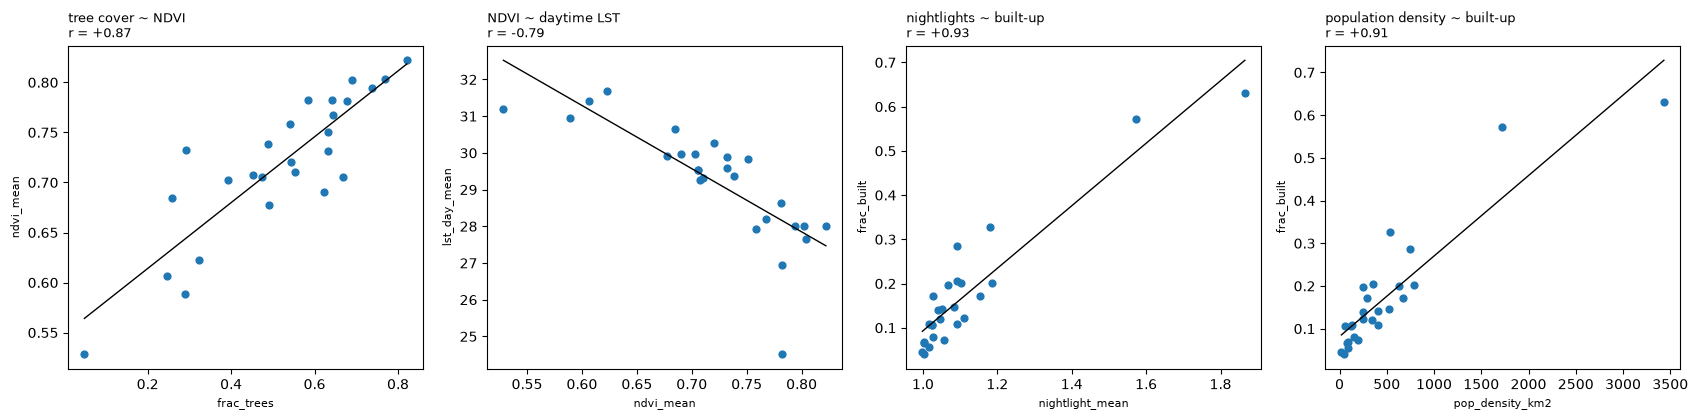

In [15]:
terrain = pd.read_csv(QUAR / "m6_batchA_terrain_srilanka.csv")
lst = pd.read_csv(QUAR / "m6_lst_terra_8day_srilanka.csv")
vi  = pd.read_csv(QUAR / "m6_vi_terra_16day_srilanka.csv")

X = (B.merge(terrain[["rdhs_name", "elev_mean", "slope_mean", "hand_mean"]], on="rdhs_name")
      .merge(lst.groupby("rdhs_name")[["lst_day_mean", "lst_night_mean", "lst_dtr"]]
                .mean().reset_index(), on="rdhs_name")
      .merge(vi.groupby("rdhs_name")[["ndvi_mean", "evi_mean"]].mean().reset_index(),
             on="rdhs_name"))

checks = [
    ("tree cover ~ NDVI",             "frac_trees",      "ndvi_mean",    +1, 0.40),
    ("NDVI ~ daytime LST",            "ndvi_mean",       "lst_day_mean", -1, 0.40),
    ("nightlights ~ built-up",        "nightlight_mean", "frac_built",   +1, 0.50),
    ("population density ~ built-up", "pop_density_km2", "frac_built",   +1, 0.50),
]
print("independent-source agreement\n")
for label, a, b, sign, floor in checks:
    r = X[a].corr(X[b])
    ok = "OK  " if sign * r >= floor else "FAIL"
    print(f"  {ok}  {label:32} r = {r:+.3f}   (expect {'>' if sign > 0 else '<'} {sign*floor:+.2f})")

fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))
for ax, (label, a, b, _, _) in zip(axes, checks):
    ax.scatter(X[a], X[b], s=24)
    xs = np.array([X[a].min(), X[a].max()])
    ax.plot(xs, np.polyval(np.polyfit(X[a], X[b], 1), xs), color="k", lw=1)
    ax.set_xlabel(a, fontsize=8); ax.set_ylabel(b, fontsize=8)
    ax.set_title(f"{label}\nr = {X[a].corr(X[b]):+.2f}", fontsize=9, loc="left")
plt.tight_layout()

for label, a, b, sign, floor in checks:
    assert sign * X[a].corr(X[b]) >= floor, f"cross-check failed: {label}"
print("\nall four cross-checks passed — batch B agrees with batches A and C")

### The urban heat island that isn't there

The obvious fifth check — more built-up, hotter days — is the one that fails, and it is worth
understanding rather than quietly dropping.

In [16]:
def partial_corr(a, b, c):
    """corr(a, b) after regressing both on c."""
    ra = X[a] - np.polyval(np.polyfit(X[c], X[a], 1), X[c])
    rb = X[b] - np.polyval(np.polyfit(X[c], X[b], 1), X[c])
    return float(np.corrcoef(ra, rb)[0, 1])

print("built-up vs thermal, at 26-district resolution\n")
for b in ["lst_day_mean", "lst_night_mean", "lst_dtr"]:
    print(f"  frac_built ~ {b:15} raw {X['frac_built'].corr(X[b]):+.3f}"
          f"   partial | elevation {partial_corr('frac_built', b, 'elev_mean'):+.3f}")

print(f"\nis elevation the confounder?  corr(built-up, elevation) = "
      f"{X['frac_built'].corr(X['elev_mean']):+.3f}  -> no, they are unrelated")
print(f"what does drive district LST:  corr(NDVI, LST day)      = "
      f"{X['ndvi_mean'].corr(X['lst_day_mean']):+.3f}")
print(f"                               corr(trees, LST day)     = "
      f"{X['frac_trees'].corr(X['lst_day_mean']):+.3f}")

hot = X.nlargest(5, "lst_day_mean")[["rdhs_name", "lst_day_mean", "frac_built", "frac_trees"]]
print("\nthe five hottest districts are not the built-up ones:")
print(hot.round(3).to_string(index=False))

built-up vs thermal, at 26-district resolution

  frac_built ~ lst_day_mean    raw +0.050   partial | elevation +0.051
  frac_built ~ lst_night_mean  raw -0.022   partial | elevation -0.176
  frac_built ~ lst_dtr         raw +0.213   partial | elevation +0.289

is elevation the confounder?  corr(built-up, elevation) = -0.027  -> no, they are unrelated
what does drive district LST:  corr(NDVI, LST day)      = -0.788
                               corr(trees, LST day)     = -0.683

the five hottest districts are not the built-up ones:
   rdhs_name  lst_day_mean  frac_built  frac_trees
  Batticaloa        31.678       0.073       0.322
    Kalmunai        31.418       0.109       0.246
      Jaffna        31.190       0.327       0.048
Killinochchi        30.946       0.106       0.289
     Colombo        30.638       0.631       0.257


**The signal is real; the aggregation unit is wrong for it.**

Controlling for elevation changes nothing, because built-up fraction and elevation are unrelated
here (r ≈ −0.03) — elevation is not the confounder. What actually governs district-mean daytime
LST is *moisture and vegetation*: NDVI correlates about −0.79 with it and tree fraction about
−0.68. Sri Lanka's dry zone is hot and sparsely built, so districts like Batticaloa and
Trincomalee sit at the top of the temperature ranking with single-digit built-up fractions, and
they cancel Colombo's contribution to the correlation.

An urban heat island is a **sub-district phenomenon** — a few kilometres across, inside a unit
averaging ~2,500 km². Averaging over the district mixes the hot core with the vegetated remainder
until the effect disappears. Note that it does survive in the **diurnal range**, where built-up
still shows a positive partial correlation: hard surfaces heat and cool faster, and taking a
difference cancels the wet/dry offset that swamps the level.

This is worth flagging beyond this notebook, because it is precisely the study's own MAUP thesis
appearing in its covariates: *a genuine physical relationship can vanish purely from the choice of
areal unit.* WP5 argues that exposure construction changes conclusions; here the same aggregation
choice erases a textbook effect. It also warns against reading M6's feature importances as
mechanism — a null on built-up would mean "not visible at 26 districts", not "no urban effect".

## 11 · Vintage audit

The table `docs/M6.md` §6 requires, and the one a reviewer will ask for: for every layer, which
years are real and which are carried forward. `carried_years` counts the window years served by an
extrapolated value.

In [17]:
audit = []
for layer, years, src in [
    ("built-up / trees / crops", LULC_YEARS, "io-lulc-annual-v02"),
    ("fragmentation",            [REF_YEAR], f"derived from land cover {REF_YEAR}"),
    ("surface water",            [GSW_EPOCH], "JRC GSW v1.4 (cumulative 1984-2020)"),
    ("population",               POP_YEARS,  "WorldPop UN-adjusted"),
    ("nightlights", HREA_YEARS, "HREA (VIIRS-derived)"),
]:
    covered = [y for y in range(WIN_START_YEAR, WIN_END_YEAR + 1) if y in years]
    carried = [y for y in range(WIN_START_YEAR, WIN_END_YEAR + 1) if y not in years]
    audit.append({"layer": layer, "source": src,
                  "years_real": f"{min(years)}-{max(years)}" if len(years) > 1 else str(years[0]),
                  "window_years_real": len(covered), "window_years_carried": len(carried),
                  "carried": ",".join(str(y) for y in carried)})
audit = pd.DataFrame(audit)
print(audit.to_string(index=False))

built_drift = 100 * (per_unit[years[-1]] - per_unit[years[0]]).mean()
span = max(1, years[-1] - years[0])
carry = WIN_END_YEAR - years[-1]
print(f"\nmean built-up change across the observed years: {built_drift:+.2f} pp over {span} years")
print(f"-> carrying {years[-1]} forward to {WIN_END_YEAR} ({carry} yr) implies a bias of order "
      f"{abs(built_drift)/span*carry:.2f} pp")
print(f"   for comparison, mean year-to-year movement is {yoy.median():.2f} pp — the carry-forward")
print(f"   bias is {'smaller than' if abs(built_drift)/span*carry < yoy.median() else 'larger than'}"
      f" the product's own year-to-year noise, so it is not the dominant uncertainty here.")

                   layer                              source years_real  window_years_real  window_years_carried                            carried
built-up / trees / crops                  io-lulc-annual-v02  2018-2023                  6                     2                          2024,2025
           fragmentation        derived from land cover 2023       2023                  1                     7 2018,2019,2020,2021,2022,2024,2025
           surface water JRC GSW v1.4 (cumulative 1984-2020)       2020                  1                     7 2018,2019,2021,2022,2023,2024,2025
              population                WorldPop UN-adjusted  2018-2020                  3                     5           2021,2022,2023,2024,2025
             nightlights                HREA (VIIRS-derived)  2018-2019                  2                     6      2020,2021,2022,2023,2024,2025

mean built-up change across the observed years: +1.01 pp over 1 years
-> carrying 2019 forward to 2025 (6 yr) i

## 12 · Freeze

In [18]:
B_CSV = QUAR / "m6_batchB_statics_srilanka.csv"
B.to_csv(B_CSV, index=False)
pop.to_csv(QUAR / "m6_batchB_population_by_year.csv", index=False)
nl.to_csv(QUAR / "m6_batchB_nightlights_by_year.csv", index=False)
water.to_csv(QUAR / "m6_batchB_water.csv", index=False)
frag.to_csv(QUAR / "m6_batchB_fragmentation.csv", index=False)

prov = {
    "notebook": "03_batchB_statics",
    "country": "sri_lanka",
    "seed": SEED,
    "window_years": [WIN_START_YEAR, WIN_END_YEAR],
    "n_units": N_UNITS,
    "n_features": len(feat_cols),
    "reference_years": {"land_cover": int(REF_YEAR), "population": int(POP_REF),
                        "nightlights": int(NL_REF), "surface_water": int(GSW_EPOCH)},
    "land_cover": {"product": "io-lulc-annual-v02 (Impact Observatory)", "res_m": 10,
                   "years": [int(y) for y in LULC_YEARS], "method": "streamed strip zonal counts"},
    "fragmentation": {"res_m": FRAG_RES_M, "year": int(REF_YEAR),
                      "metrics": ["lc_shannon", "edge_density_m_km2", "lpi_pct", "built_lpi_pct"],
                      "note": "edge density is resolution-dependent; comparable only within this table"},
    "surface_water": {"product": "JRC GSW v1.4", "res_m": 30, "epoch": GSW_EPOCH,
                      "permanent_threshold_occurrence_pct": 90,
                      "distance_grid_res_m": int(G_W.res * 111320 * BLOCK)},
    "population": {"product": "WorldPop UN-adjusted 100 m", "years": [int(y) for y in POP_YEARS],
                   "national_total_M": {str(k): round(v, 3) for k, v in national.items()},
                   "note": "sum unweighted (counts); density uses equal-area district area"},
    "nightlights": {"product": "HREA (VIIRS-derived)", "years": [int(y) for y in HREA_YEARS],
                    "substitution": "monthly VIIRS DNB (EOG) requires a registered account; "
                                    "HREA is the anonymous VIIRS-derived substitute, annual not monthly"},
    "geographic_weighting": "cos(latitude) weights on all EPSG:4326 rasters; projected rasters unweighted",
    "vintage_carry_forward": audit.to_dict("records"),
    "geometry_sha256_16": prov0["geometry_sha256_16"],
    "output_sha256_16": hashlib.sha256(B_CSV.read_bytes()).hexdigest()[:16],
}
(QUAR / "nb03_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps(prov, indent=2)[:2600])
print("\nwritten:", B_CSV)

{
  "notebook": "03_batchB_statics",
  "country": "sri_lanka",
  "seed": 20260612,
  "window_years": [
    2018,
    2025
  ],
  "n_units": 26,
  "n_features": 18,
  "reference_years": {
    "land_cover": 2023,
    "population": 2020,
    "nightlights": 2019,
    "surface_water": 2020
  },
  "land_cover": {
    "product": "io-lulc-annual-v02 (Impact Observatory)",
    "res_m": 10,
    "years": [
      2018,
      2019,
      2020,
      2021,
      2022,
      2023
    ],
    "method": "streamed strip zonal counts"
  },
  "fragmentation": {
    "res_m": 30,
    "year": 2023,
    "metrics": [
      "lc_shannon",
      "edge_density_m_km2",
      "lpi_pct",
      "built_lpi_pct"
    ],
    "note": "edge density is resolution-dependent; comparable only within this table"
  },
  "surface_water": {
    "product": "JRC GSW v1.4",
    "res_m": 30,
    "epoch": 2020,
    "permanent_threshold_occurrence_pct": 90,
    "distance_grid_res_m": 222
  },
  "population": {
    "product": "WorldPop UN-

## 13 · Recap

In [19]:
recap = pd.DataFrame([
    ("land-cover years",        len(LULC_YEARS),                     f"{min(LULC_YEARS)}-{max(LULC_YEARS)}, 10 m"),
    ("pixels per island-year",  f"{lc[lc.year==REF_YEAR].lc_n_px.sum()/1e6:,.0f} M", "streamed, never held"),
    ("batch B features",        len(feat_cols),                      "per district"),
    ("built-up, island mean",   f"{100*ref['frac_built'].mean():.1f}%",  f"{REF_YEAR}"),
    ("tree cover, island mean", f"{100*ref['frac_trees'].mean():.1f}%",  f"{REF_YEAR}"),
    ("permanent water",         f"{100*water['permanent_water_frac'].mean():.2f}%", "occurrence >= 90%"),
    ("population",              f"{national[POP_REF]:.2f} M",        f"WorldPop {POP_REF}"),
    ("collinear pairs |r|>0.8", len(hi),                             f"of {len(feat_cols)*(len(feat_cols)-1)//2}"),
    ("layers needing carry-fwd",int((audit.window_years_carried > 0).sum()), f"of {len(audit)}"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

                quantity   value                 note
        land-cover years       6      2018-2023, 10 m
  pixels per island-year   662 M streamed, never held
        batch B features      18         per district
   built-up, island mean   17.3%                 2023
 tree cover, island mean   52.0%                 2023
         permanent water   0.91%    occurrence >= 90%
              population 21.12 M        WorldPop 2020
 collinear pairs |r|>0.8      14               of 153
layers needing carry-fwd       5                 of 5


---

### Design notes carried forward

**Batch B is collinear, and collinear across batches.** Built-up, nightlights and population
density are close to three measurements of one latent "settlement" variable (all pairwise |r| >
0.9), and tree fraction is nearly interchangeable with batch C's NDVI (r ≈ 0.87). Combined with
notebook 01's finding that batch A spans roughly two independent dimensions, the M6 feature set
has far fewer effective dimensions than it has columns. **Stability selection inside the spatial
folds is not optional**, and single-variable importance rankings from this feature set should not
be quoted.

**Aggregation can erase a real effect (§10).** The urban heat island is absent at 26-district
resolution even though it is one of the best-established relationships in the field. Treat any M6
null as a statement about this areal unit, not about the physics.

**The interim gate can now be run.** `M6.md` §9.5 asks that M6 be fitted on batch A + B alone
before the full ladder, to confirm it beats M0 (season) — but note that A + B is *entirely
static*, so as notebook 02 §15 showed, that fit has no way to express *when*. Expect it to fail
the gate by construction. That is informative about the gate, not about geomatics: the honest
version of the interim check is A + B against a **cross-sectional** baseline, not a weekly one.

**Join to a single epoch, not year by year.** That is the opposite of what was planned going in,
and §4 is why: the land-cover product's year-to-year wobble is large relative to its net movement,
so a year-matched join would feed the model reclassification noise dressed as urbanisation. The
per-year tables (`*_by_year.csv`) are frozen anyway — they are the evidence for that call, and they
keep it reversible if a future vintage of the product proves more stable.

**What is still missing from M6's 16.** Batch D remains: healthcare access (#13, OSM), relative
wealth (#14, Meta RWI on HDX — `lightscore` from §8 is the fallback proxy), connectivity (#15) and
a proper rice-paddy phenology (#16, partly covered by the cropland fraction here).